## Import and installation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os 
import re

In [4]:
import anndata as ad
import scanpy as sc
import muon as mu
import mofapy2
import mofax
from mofapy2.run.entry_point import entry_point

/opt/conda/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [7]:
# Need to do once in the new container to deal with mofapy2 bug: one line of code is incompatibile with newer versions of pandas
#with STalign and mofapy2 require two different pandas versions and are incompatible in one container, later maybe will fix later
#read the file where error occurs
with open("/opt/conda/lib/python3.13/site-packages/mofapy2/core/nodes/Sigma_node.py", "r") as f:
    content = f.read()
#print(content[3577:3693])
#make the fix
content_fixed = content.replace(
    content[3577:3693],
    "self.groupsidx = pd.factorize(np.array(self.group_labels))[0]"
)

#verify the replacement happened
assert content != content_fixed, "Replacement didn't happen - check the exact string"

#write back
with open("/opt/conda/lib/python3.13/site-packages/mofapy2/core/nodes/Sigma_node.py", "w") as f:
    f.write(content_fixed)

print("Error is fixed")

Error is fixed


## Load data 

In [5]:
#function to load the data and combine many slices if necessary 
def load_data(data_dir, file_names=None, all_files=False):
    if all_files:
        files_all = [f for f in os.listdir(data_dir) if f.endswith('.h5ad')]
    else:
        files_all = file_names
    if len(file_names)==1:
        combined_adata = sc.read_h5ad(os.path.join(data_dir, file_names[0]))
    else:
        adatas = {}
        for file in files_all:
            slice_name = file.replace('.h5ad', '')
            adata = sc.read_h5ad(os.path.join(data_dir, file))
            adata.obs_names = [f"{slice_name}_{x}" for x in adata.obs_names]
            adata.obs['slice'] = slice_name
            adatas[slice_name] = adata
            combined_adata = sc.concat(adatas.values(), label='slice', keys=list(adatas.keys()))

    #ensure spatial coordinates are in obsm['spatial']
    if 'spatial' not in combined_adata.obsm:
        combined_adata.obsm['spatial'] = combined_adata.obs[['x', 'y']].to_numpy()

    return combined_adata

In [17]:
m = mofax.mofa_model("ST_model1.hdf5")

In [18]:
m

MOFA+ model: ST model1
Samples (cells): 19814
Features: 2000
Groups: group1 (19814)
Views: rna (2000)
Factors: 4
Expectations: Sigma, W, Z

MEFISTO:
Covariates available: imagerow, imagecol

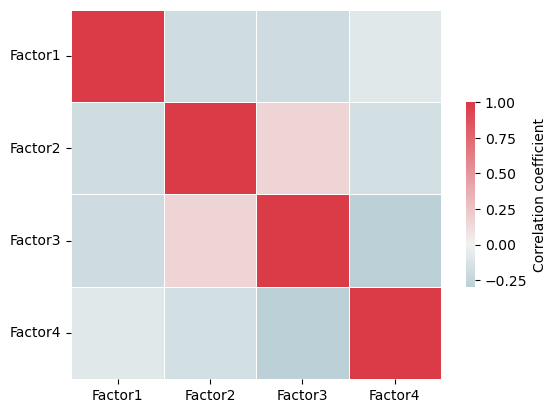

In [20]:
mofax.plot_factors_correlation(m);

In [6]:
def visualize_factors(combined_adata, mod_num=5, num_factors=10):
    mod_name='ST_model' + str(mod_num)+'.hdf5'
    
    m = mofax.mofa_model(mod_name)
    factor_df=m.get_factors(df=True)
    dict_rename={f"Factor{i}" : f"Factor{i}_model"+str(mod_num) for i in range(1,num_factors+1)}
    factor_df = factor_df.rename(columns=dict_rename)
    combined_adata.obs = combined_adata.obs.join(factor_df)

    fig, ax = plt.subplots(2,5, figsize=(24, 6))
    for factor_idx in range(1,11):
        sc.pl.embedding(
            combined_adata,
            basis='spatial',
            color=f'Factor{factor_idx}_model{str(mod_num)}',
            size=50,
            color_map='viridis',
            show=False,
            ax=ax[(factor_idx-1)//5,(factor_idx-1)%5])
        ax[(factor_idx-1)//5, (factor_idx-1)%5].set_title(f'Factor {factor_idx} Spatial Pattern')
    plt.show()
    

In [8]:
def pearson_highly_variable_genes(adata, n_top_genes=2000):
    adata.var['residual_variances'] = np.var(adata.X, axis=0).T
    hv_genes = adata.var\
        .sort_values(by='residual_variances', ascending=False)\
        .head(n_top_genes).index
    adata.var['highly_variable'] = False
    adata.var.loc[hv_genes, 'highly_variable'] = True
    return

In [9]:
def read_and_preprocess_data(file_names, data_dir="/home/jovyan/data/"):
    combined_adata=load_data(data_dir=data_dir, file_names=file_names)
#compute percent_mt and qc metrics
    combined_adata.var["mt"] = combined_adata.var_names.str.startswith("mt-")
    sc.pp.calculate_qc_metrics(combined_adata, qc_vars=["mt"], inplace=True)
    sc.pp.filter_cells(combined_adata, min_counts=100)
    sc.pp.filter_genes(combined_adata, min_cells=1)

    #save raw counts to a layer
    combined_adata.layers['counts'] = combined_adata.X.copy()

    #preprocesing
    #calculate Pearson residuals
    sc.experimental.pp.normalize_pearson_residuals(combined_adata)

    #save Pearson residuals to a layer
    combined_adata.layers['residuals'] = combined_adata.X.copy()

    #find highly variable genes using Pearson residuals
    pearson_highly_variable_genes(combined_adata)

    return combined_adata



In [17]:
combined_adata = read_and_preprocess_data(file_names=["T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad"])

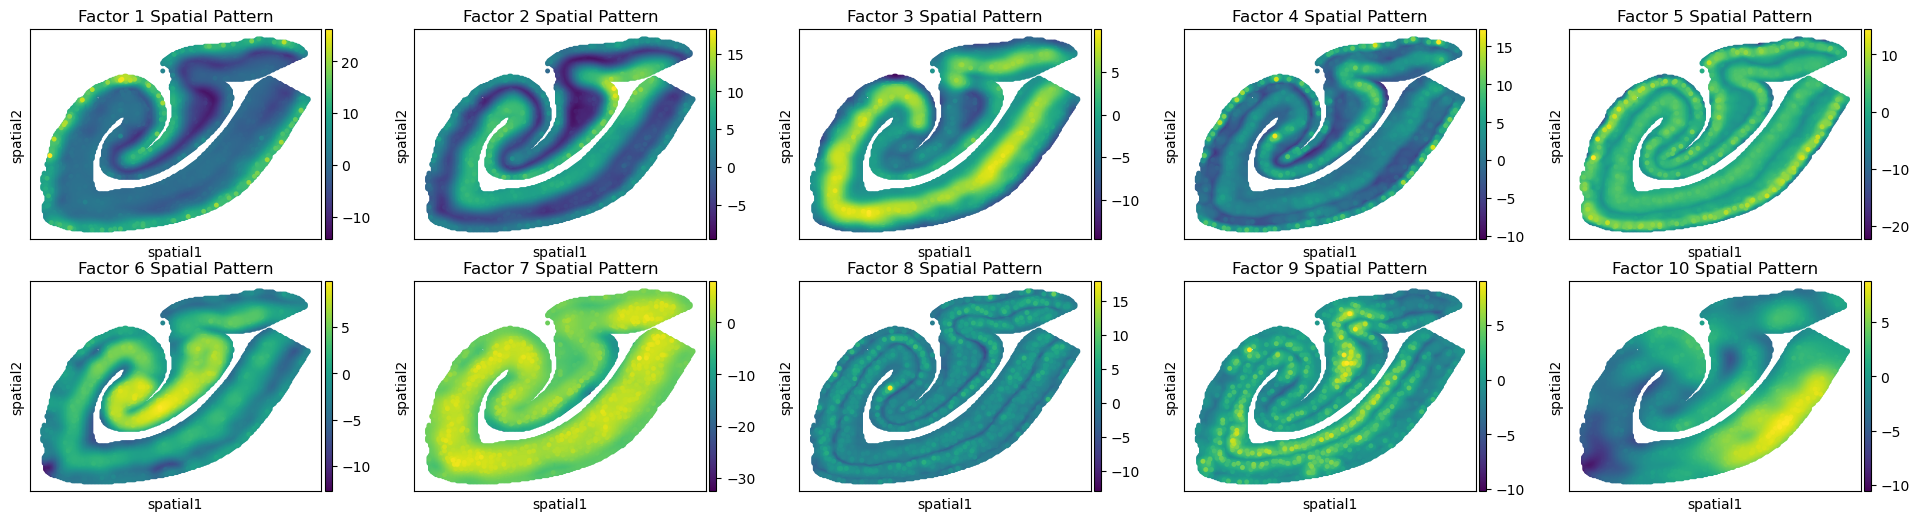

In [21]:
visualize_factors(combined_adata, mod_num=7, num_factors=10)

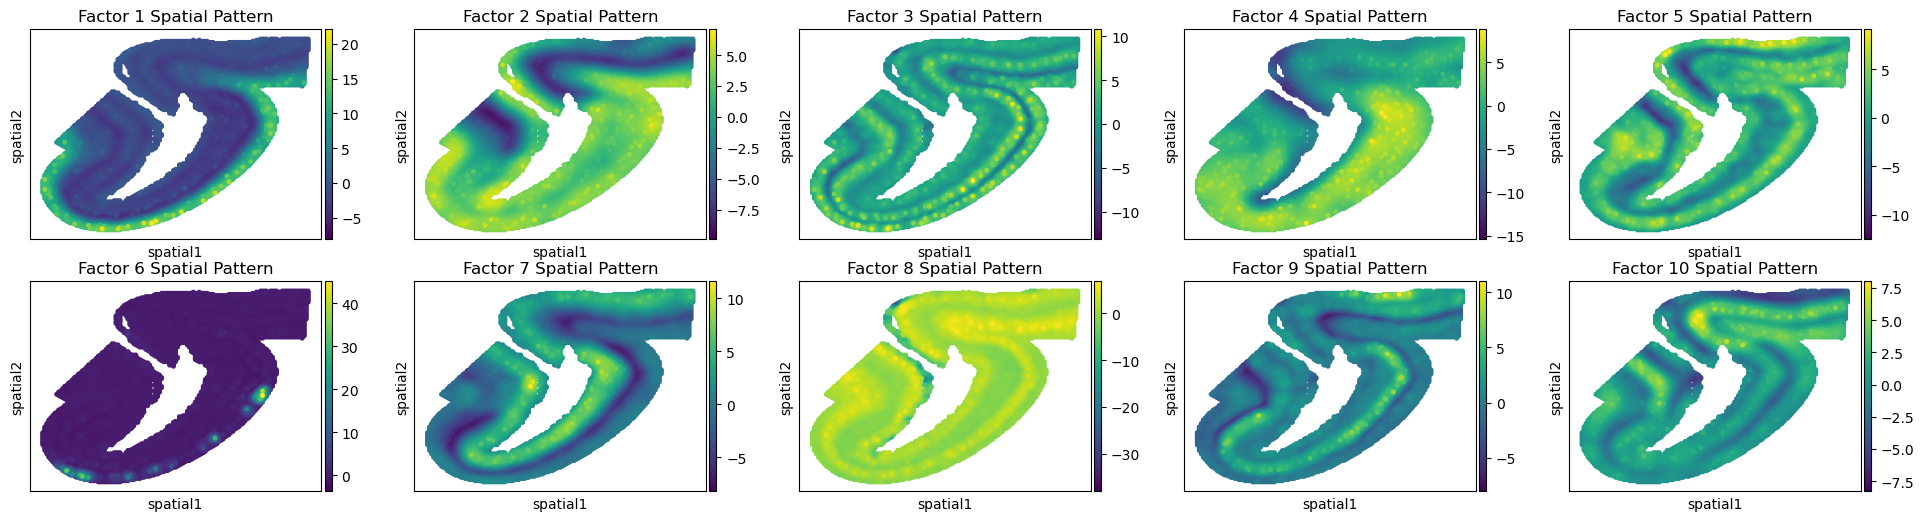

In [22]:
combined_adata2 = read_and_preprocess_data(file_names=["T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad"])
visualize_factors(combined_adata2, mod_num=8, num_factors=10)

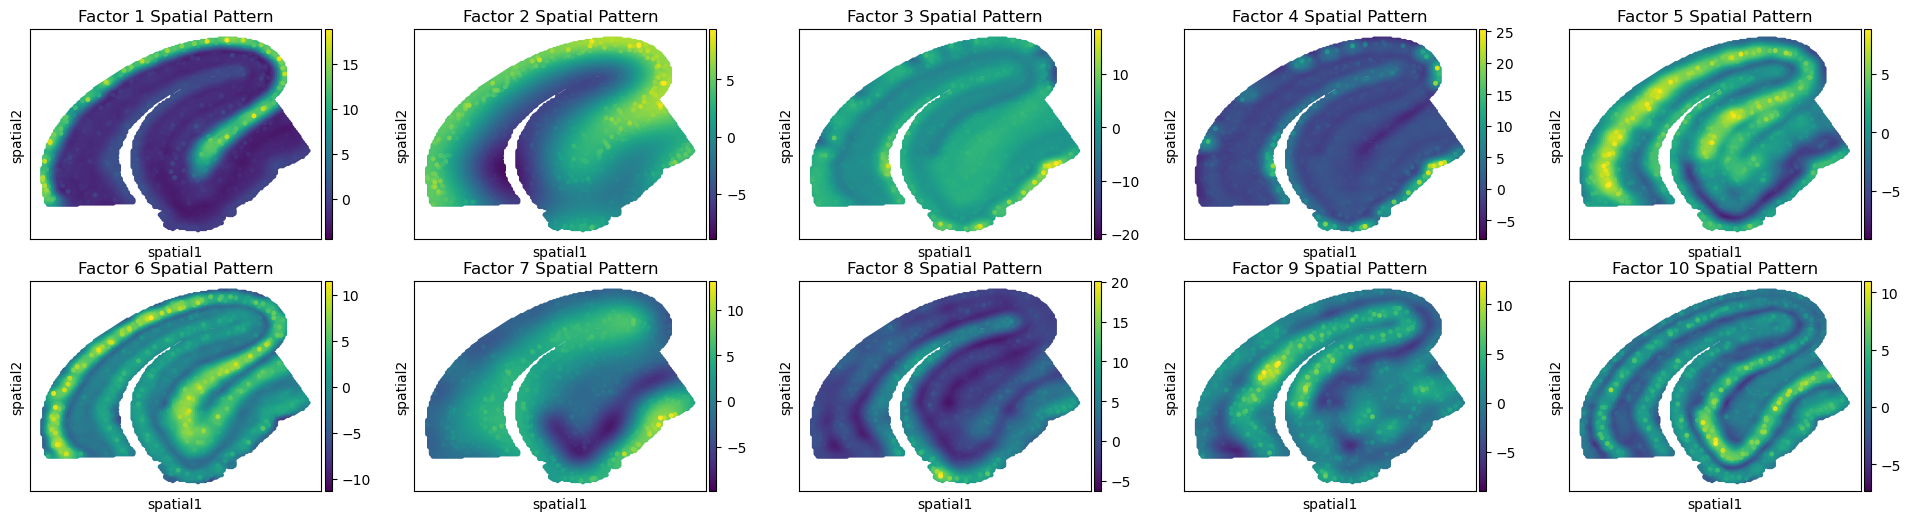

In [10]:
combined_adata3 = read_and_preprocess_data(file_names=["T1092_MT63_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad"])
visualize_factors(combined_adata3, mod_num=9, num_factors=10)

In [ ]:
#combined_adata4 = read_and_preprocess_data(file_names=["T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered.h5ad"])
#visualize_factors(combined_adata4, mod_num=10, num_factors=10)

In [ ]:
#combined_adata5 = read_and_preprocess_data(file_names=["T1099_MT67_7M_Visual_Sub-CTX_V12_b100_filtered.h5ad"])
#visualize_factors(combined_adata5, mod_num=11, num_factors=10)

Additional visualization

## Visualization with mofax

In [ ]:
# top genes per factor

In [ ]:
# top1 gene visualization for each factor

In [ ]:
#top-50 Gene expression changes per factor 1 across slices

In [ ]:
import mofax as mfx

model = mfx.mofa_model("trained_mofaplus_model.hdf5")